In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
# tab_gid = "908803302"
tab_gid = "1990888583" 
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"

In [3]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1.png"):
    compression_order = ["Original", "8-bit", "4-bit"]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Compression", y=score_col, hue="Model", marker="o")
    
    # Get the current axis
    ax = plt.gca()
    # new_labels = ["Full" if label.get_text() == "Original" else label.get_text() 
    #              for label in ax.get_xticklabels()]
    # ax.set_xticklabels(new_labels)
    
    # Create the legend and place it in the upper center (just below title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, fontsize=12, frameon=False)
    
    # plt.title(f"{miaName}({score_col}) Score Across Compression Levels for Different Pythia Models", pad=30)
    plt.ylabel(f"{score_col} Score ({miaName})")
    plt.xlabel("Precision Level")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}", dpi=300, bbox_inches="tight")
    plt.show()

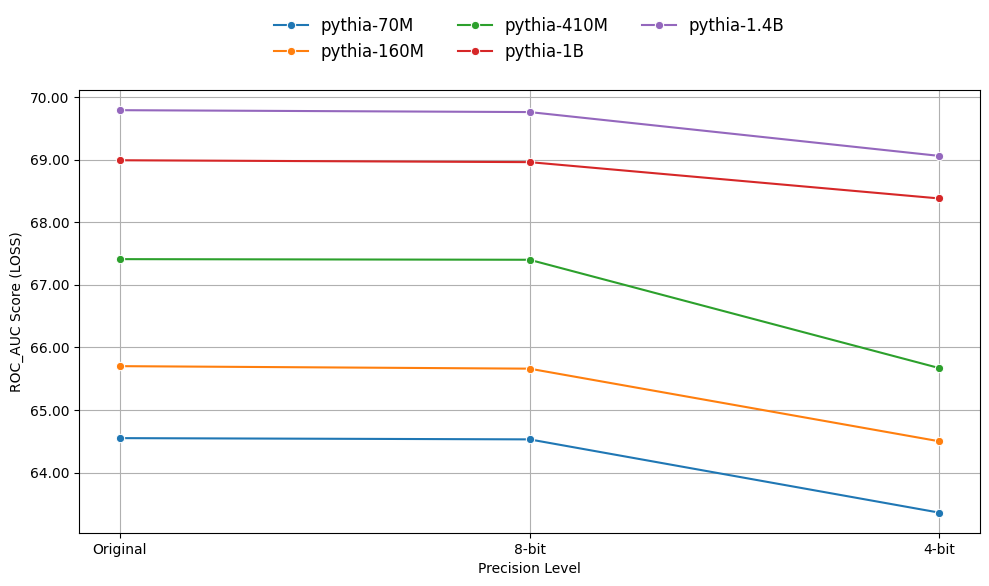

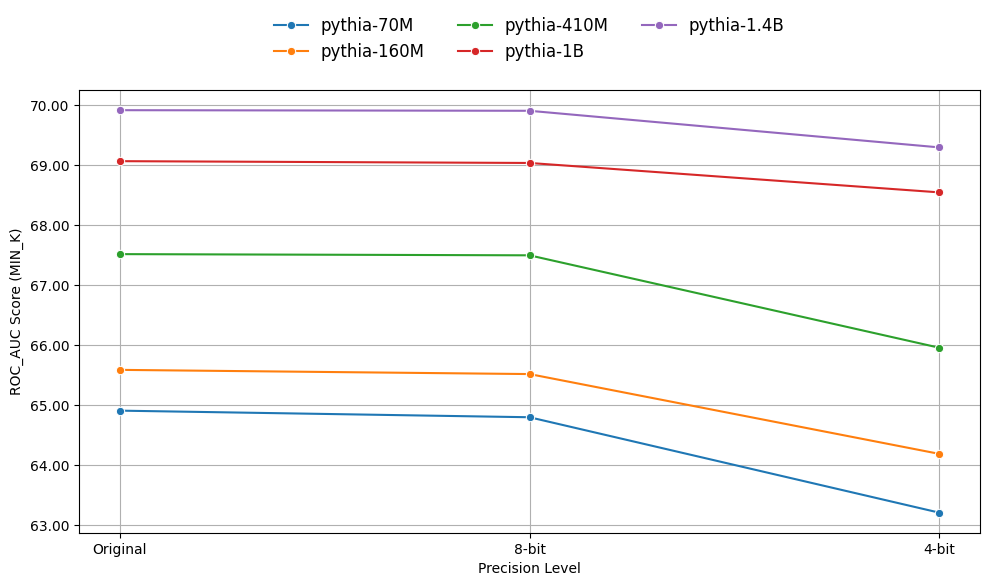

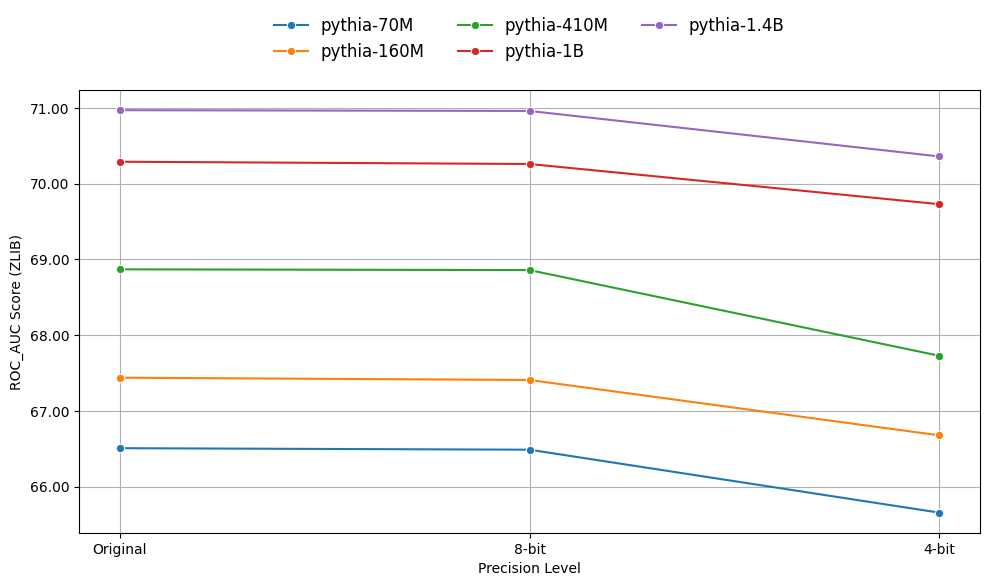

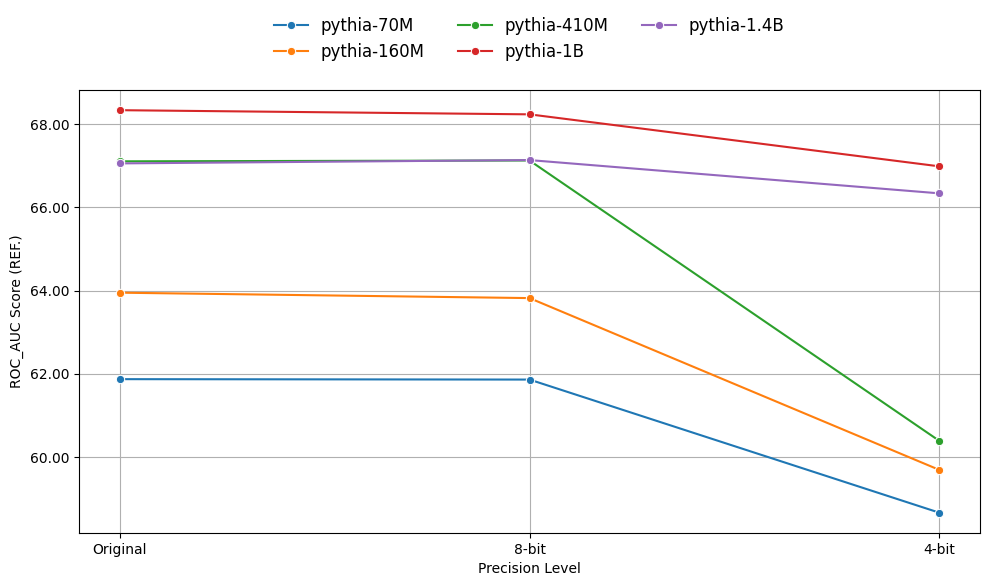

In [4]:
limit = 15
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"]).iloc[:limit, :]
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"]).iloc[:limit, :]
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-2.2.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"]).iloc[:limit, :]
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-2.3.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"]).iloc[:limit, :]
df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-2.4.png")

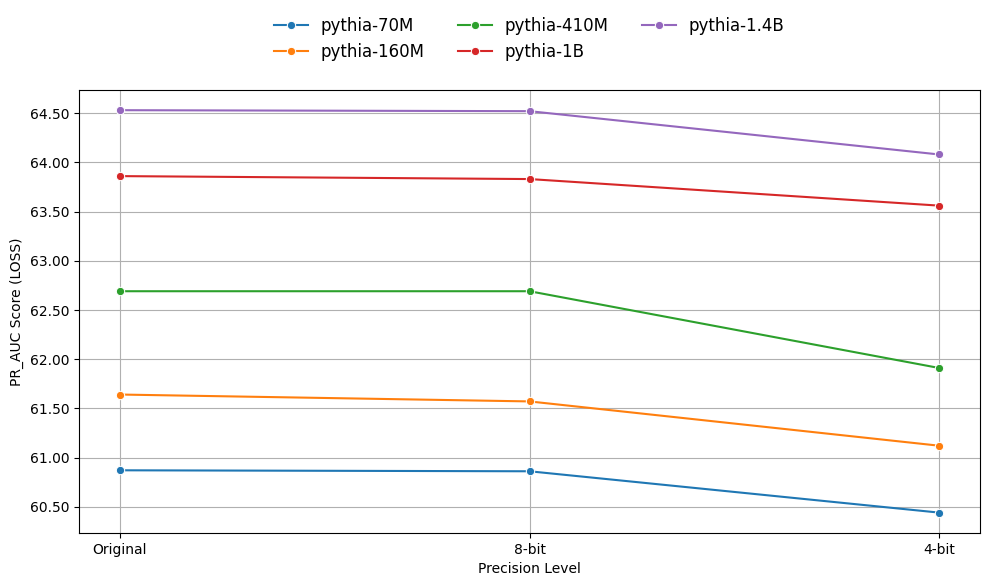

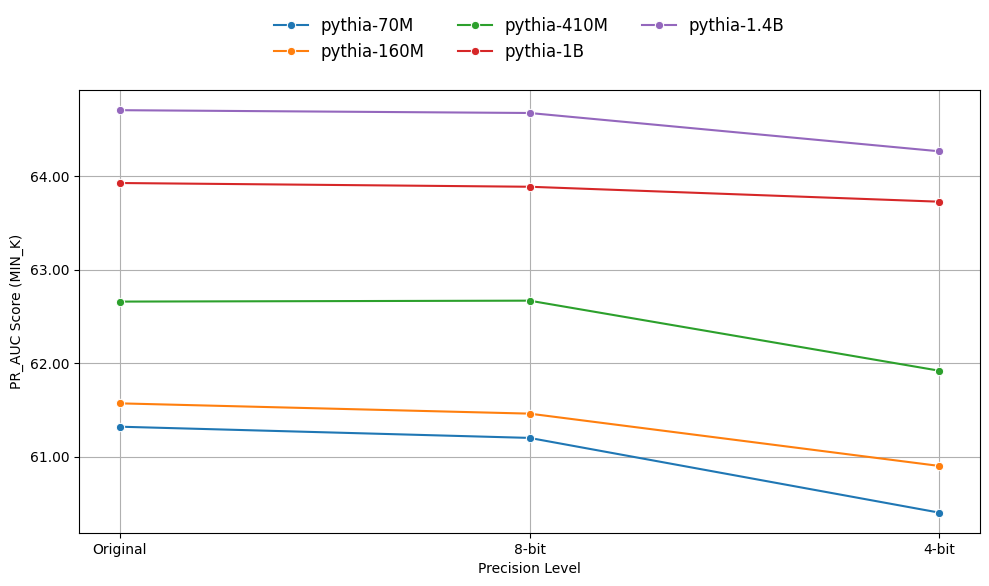

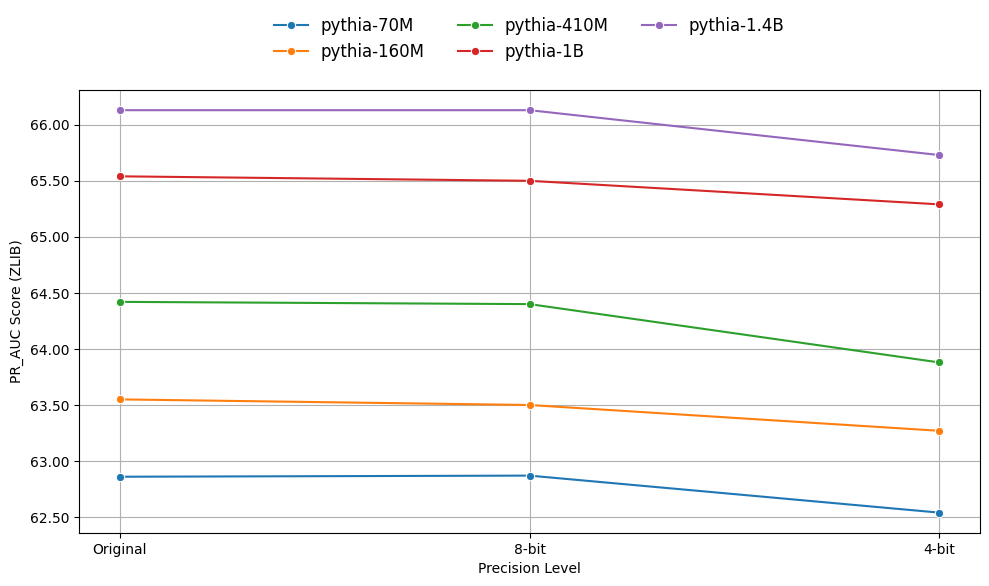

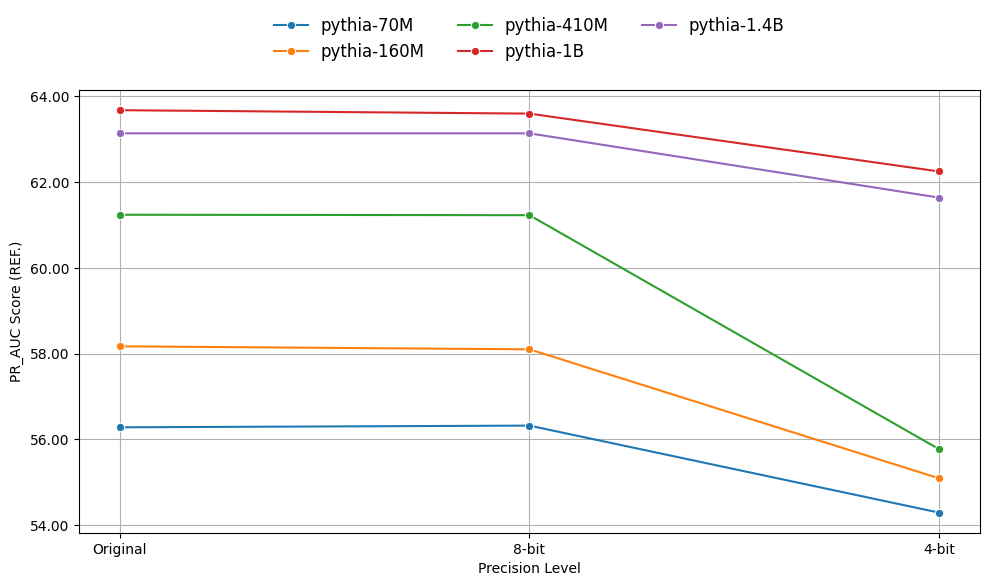

In [5]:
metric = "PR_AUC"

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", metric]).iloc[:limit, :]
graph_roc_auc(df, score_col=metric, miaName="LOSS", fileName="RQ-2.5.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.1"]).iloc[:limit, :]
df = df.rename(columns={"PR_AUC.1": metric})
graph_roc_auc(df, score_col=metric, miaName="MIN_K", fileName="RQ-2.6.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.2"]).iloc[:limit, :]
df = df.rename(columns={"PR_AUC.2": metric})
graph_roc_auc(df, score_col=metric, miaName="ZLIB", fileName="RQ-2.7.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.3"]).iloc[:limit, :]
df = df.rename(columns={"PR_AUC.3": metric})
graph_roc_auc(df, score_col=metric, miaName="REF.", fileName="RQ-2.8.png")

## second part

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_82681/2901445725.py:13: FutureWarning: The provided callable <function mean at 0x1194b2670> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


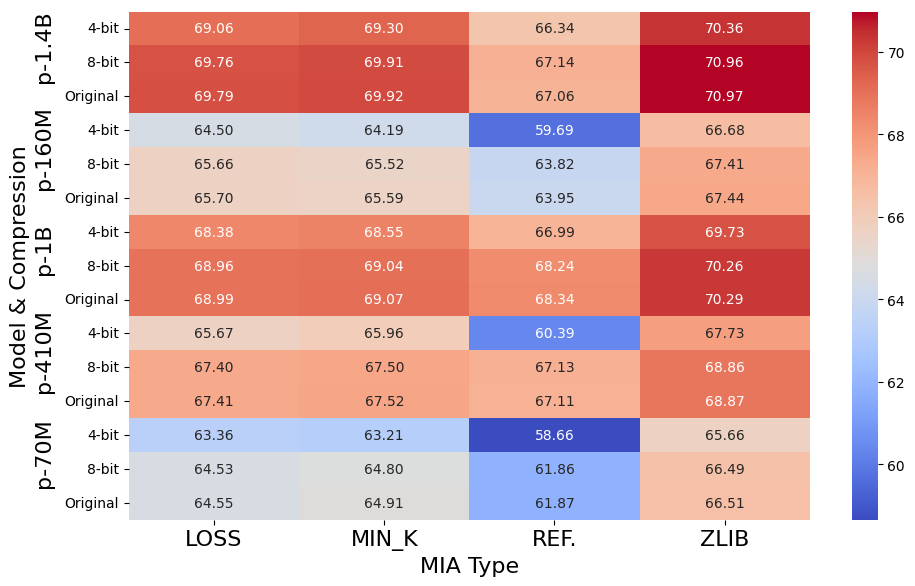

In [6]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]).iloc[:limit, :]
df.rename(columns={"ROC_AUC": "LOSS", "ROC_AUC.1": "MIN_K", "ROC_AUC.2": "ZLIB", "ROC_AUC.3": "REF."}, inplace=True)
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF.']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# === Plotting with custom group labels ===
fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    cbar=True, 
    # vmin=55.5, vmax=71,
    ax=ax
)

# Hide y-axis label
ax.set_ylabel("")

# Customize y-tick labels to show only compression
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(compression_labels, rotation=0)

# === Add model labels manually for each block ===
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()
renamed_models = [model.replace("pythia", "p") for model in unique_models]


# Count how many rows per model
row_counts = models.value_counts().sort_index()
start_idx = 0
for model, r_model in zip(unique_models, renamed_models):
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5  # Center of the block
    ax.text(
        -0.5, center_row, r_model, 
        rotation=90, va='center', ha='center',
        fontsize=16, color='black'
    )
    start_idx += count

# Final formatting
ax.set_xlabel("MIA Type", fontsize=16)
plt.xticks(rotation=0, fontsize=16)
plt.ylabel("Model & Compression", labelpad=25, fontsize=16)


plt.tight_layout()
plt.savefig("./output/roc_auc_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_82681/1975274065.py:15: FutureWarning: The provided callable <function mean at 0x1194b2670> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


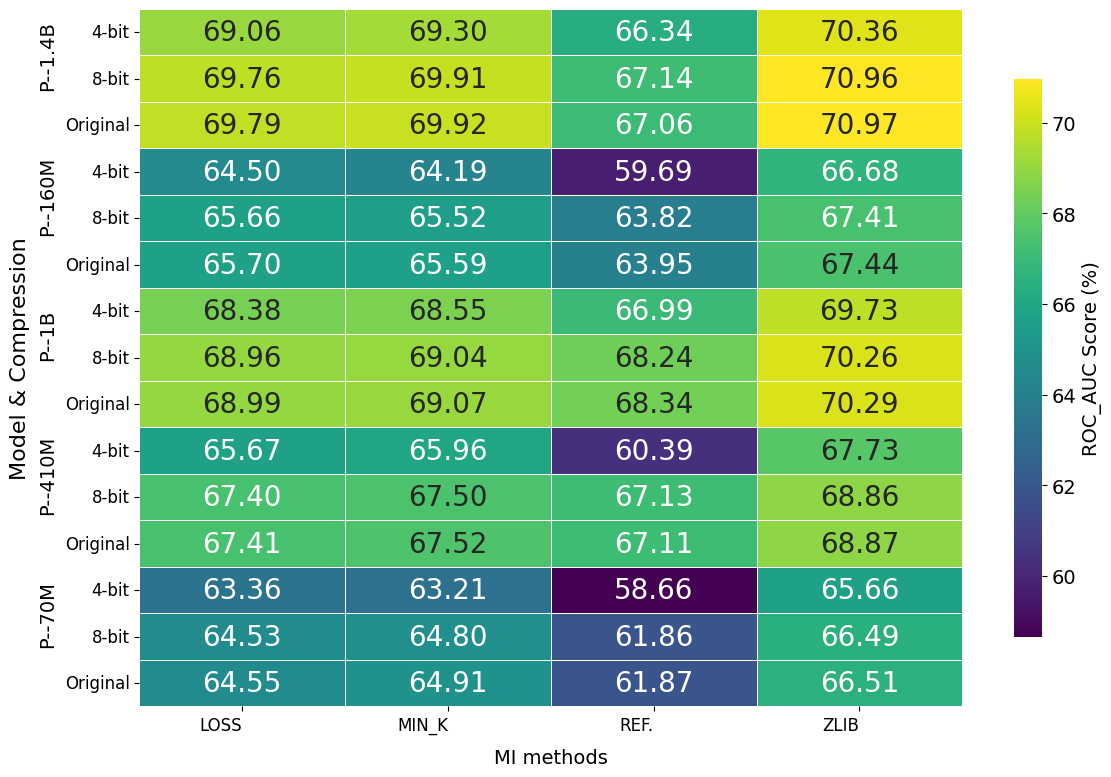

In [28]:
# Data preparation (unchanged)
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]).iloc[:limit, :]
df.rename(columns={"ROC_AUC": "LOSS", "ROC_AUC.1": "MIN_K", "ROC_AUC.2": "ZLIB", "ROC_AUC.3": "REF."}, inplace=True)
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF.']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

# Create long format and pivot table (unchanged)
df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# ==== Enhanced Plotting ====
plt.figure(figsize=(12, 8))  # Slightly larger figure
ax = plt.gca()

# 1. Improved Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='viridis',  # More perceptually uniform colormap
    fmt='.2f', 
    cbar_kws={'label': 'ROC_AUC Score (%)', 'shrink': 0.8},
    linewidths=0.5,  # Add grid lines between cells
    linecolor='white',  # White grid lines
    annot_kws={'fontsize': 20},  # Larger annotation text
    ax=ax
)

# 2. Enhanced Axis Labels
ax.set_xlabel("MI methods", fontsize=14, labelpad=10)
ax.set_ylabel("")  # Remove default y-label

# 3. Improved Y-axis ticks (compression labels)
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(
    compression_labels, 
    rotation=0, 
    fontsize=12,
    va='center'  # Better vertical alignment
)

# 4. Model Group Labels with Better Formatting
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()
renamed_models = [model.replace("pythia", "P-") for model in unique_models]  # More readable prefix

row_counts = models.value_counts().sort_index()
start_idx = 0
for model, r_model in zip(unique_models, renamed_models):
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5
    ax.text(
        -0.4, center_row, r_model,  # Moved slightly further left
        rotation=90,  # Horizontal text for better readability
        va='center', 
        ha='right',
        fontsize=14, 
        color='black',
        # fontweight='bold'  # Emphasize model names
    )
    start_idx += count

# 5. Final Adjustments
plt.xticks(rotation=0, ha='right', fontsize=12)  # Diagonal x-labels for better fit
# plt.title("Model Vulnerability to MIA Attacks by Compression Type", pad=20, fontsize=16)
plt.ylabel("Model & Compression", labelpad=25, fontsize=16)

# Add subtle grid for better value comparison
ax.hlines(range(len(pivot_df)), *ax.get_xlim(), colors='white', linewidths=0.5)

plt.tight_layout()
plt.savefig("./output/roc_auc_heatmap.pdf", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_51422/2678783353.py:14: FutureWarning: The provided callable <function mean at 0x10d17da60> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


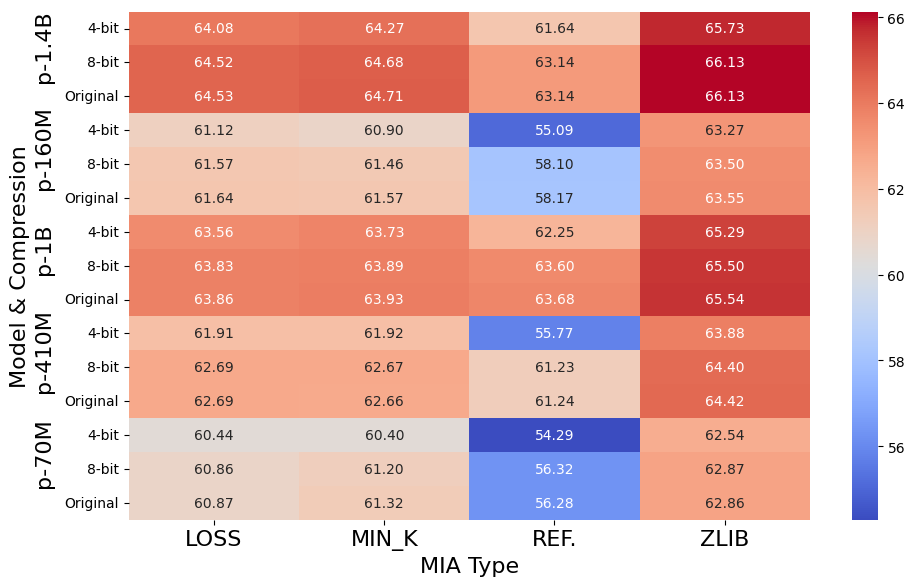

In [44]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]).iloc[:limit, :]
df.rename(columns={"PR_AUC": "LOSS", "PR_AUC.1": "MIN_K", "PR_AUC.2": "ZLIB", "PR_AUC.3": "REF."}, inplace=True)
# === Prepare the data ===
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF.']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# === Plotting with custom group labels ===
fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    cbar=True, 
    # vmin=55.5, vmax=71,
    ax=ax
)

# Hide y-axis label
ax.set_ylabel("")

# Customize y-tick labels to show only compression
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(compression_labels, rotation=0)

# === Add model labels manually for each block ===
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()
renamed_models = [model.replace("pythia", "p") for model in unique_models]


# Count how many rows per model
row_counts = models.value_counts().sort_index()
start_idx = 0
for model, r_model in zip(unique_models, renamed_models):
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5  # Center of the block
    ax.text(
        -0.5, center_row, r_model, 
        rotation=90, va='center', ha='center',
        fontsize=16, color='black'
    )
    start_idx += count

# Final formatting
# ax.set_title("Comparison of MIA Performance w.r.t. PR_AUC  for Different Compression Levels and Models")
ax.set_xlabel("MIA Type", fontsize=16)
plt.xticks(rotation=0, fontsize=16)
plt.ylabel("Model & Compression", labelpad=25, fontsize=16)

plt.tight_layout()
plt.savefig("./output/pr_auc_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_82681/979522549.py:15: FutureWarning: The provided callable <function mean at 0x1194b2670> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


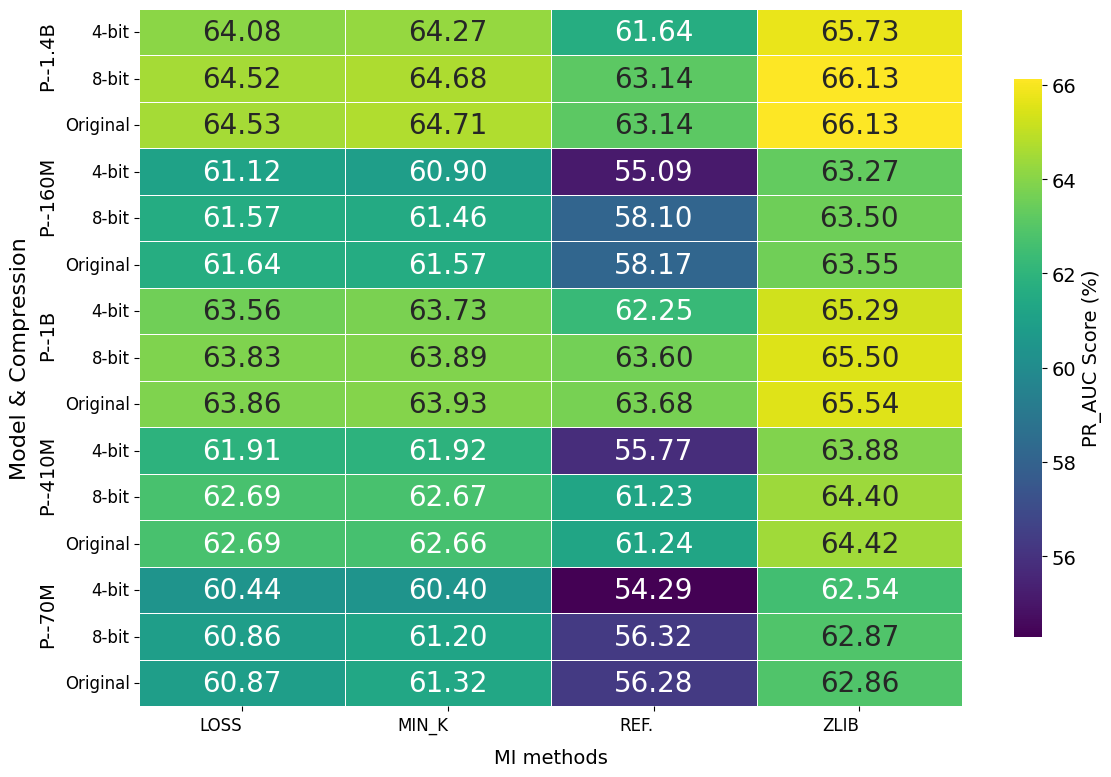

In [29]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]).iloc[:limit, :]
df.rename(columns={"PR_AUC": "LOSS", "PR_AUC.1": "MIN_K", "PR_AUC.2": "ZLIB", "PR_AUC.3": "REF."}, inplace=True)
# Data preparation (unchanged)
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF.']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

# Create long format and pivot table (unchanged)
df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# ==== Enhanced Plotting ====
plt.figure(figsize=(12, 8))  # Slightly larger figure
ax = plt.gca()

# 1. Improved Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='viridis',  # More perceptually uniform colormap
    fmt='.2f', 
    cbar_kws={'label': 'PR_AUC Score (%)', 'shrink': 0.8},
    linewidths=0.5,  # Add grid lines between cells
    linecolor='white',  # White grid lines
    annot_kws={'fontsize': 20},  # Larger annotation text
    ax=ax
)

# 2. Enhanced Axis Labels
ax.set_xlabel("MI methods", fontsize=14, labelpad=10)
ax.set_ylabel("")  # Remove default y-label

# 3. Improved Y-axis ticks (compression labels)
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(
    compression_labels, 
    rotation=0, 
    fontsize=12,
    va='center'  # Better vertical alignment
)

# 4. Model Group Labels with Better Formatting
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()
renamed_models = [model.replace("pythia", "P-") for model in unique_models]  # More readable prefix

row_counts = models.value_counts().sort_index()
start_idx = 0
for model, r_model in zip(unique_models, renamed_models):
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5
    ax.text(
        -0.4, center_row, r_model,  # Moved slightly further left
        rotation=90,  # Horizontal text for better readability
        va='center', 
        ha='right',
        fontsize=14, 
        color='black',
        # fontweight='bold'  # Emphasize model names
    )
    start_idx += count

# 5. Final Adjustments
plt.xticks(rotation=0, ha='right', fontsize=12)  # Diagonal x-labels for better fit
# plt.title("Model Vulnerability to MIA Attacks by Compression Type", pad=20, fontsize=16)
plt.ylabel("Model & Compression", labelpad=25, fontsize=16)

# Add subtle grid for better value comparison
ax.hlines(range(len(pivot_df)), *ax.get_xlim(), colors='white', linewidths=0.5)

plt.tight_layout()
plt.savefig("./output/pr_auc_heatmap.pdf", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()